# Lab 2: Variational Algorithms

<div class="youtube-wrapper">
    <iframe src="https://www.youtube.com/embed/bNbdZ4SSjtE" title="YouTube video player" frameborder="0" allow="accelerometer; autoplay; clipboard-write; encrypted-media; gyroscope; picture-in-picture" allowfullscreen></iframe>
</div>

- Download the notebook: <a href="/content/summer-school/2021/resources/lab-notebooks/lab-2.ipynb">[en]</a> <a href="/content/summer-school/2021/resources/lab-notebooks/lab-2-ja.ipynb">[ja]</a>

In this lab, you will learn how to create and work with parameterized quantum circuits and quadratic programs, and how to solve optimization problems using the Quantum Approximate Optimization Algorithm.

* Graded Exercise 2-1: MaxCut
* Graded Exercise 2-2: MaxCut to Quadratic Program
* Graded Exercise 2-3: Quantum Approximate Optimization Algorithm
* Graded Exercise 2-4: Conditional Value at Risk



### Lab Tips / Hints

**Exercise 1:**
For any given cut, think of the scenario when an edge E would contribute to the cut value -- either of its vertices have to belong to different sets. Intuitively, it follows that the weight of an edge is added to the cut value only if the bits corresponding to its vertices in the given *bitstring* are not identical.
After generating the histogram showing the cut value for all possible n-bit strings, the bitstring with the maximum cut value should be your max-cut.

**Exercise 2:**
Create a general QUBO cost function with QUBO Matrix Q = -W (negation of the weight matrix) and QUBO Vector c = sum of all entries in each row of the weight matrix W. 
Use binary optimisation variables in Quadratic Program and maximise it.

**Exercise 3:**
For each layer i of p, use the following expression:
[Image: Screenshot 2021-08-06 at 4.10.10 AM.png] Use RZ, RZZ and RX gates to the expressions in their corresponding brackets as shown in the image above. While applying RZZ gates to Qjk, make sure that j is not equal to k else it would make it a single qubit and entanglement would not make sense. You can check how the final circuit looks like using the draw() function.

**Exercise 4:**
Do not forget to order the cut-values Ci in decreasing order!
Simply get the number of best cuts n that are to be considered for our optimisation process by multiplying the number of shots by alpha. 
The top n cuts would be the first n Ci. 
Finally, calculate the energy.

Please refer to the doc here (https://cdn.discordapp.com/attachments/866843353408995328/867471161255919666/Lab2_hints.pdf). It contains a lot of additional useful hints.

<!-- ::: q-block.reminder -->

### FAQ (Exercise 1 & 2)

<details>
  <summary>Is trajectory like a log of different parameters that have been tried?</summary>
Yes, the trajectory tracks the parameters and corresponding energies of the optimization process
</details>

<details>
  <summary>How do we know that a _higher_ energy level isn't reached at a bigger depth?</summary>
Since we only enlarge the space of quantum states that we optimise over, the global optimum is actually guaranteed to get better with increasing depth. However, since we introduce more parameters when increasing the depth it also becomes more difficult to actually find this optimum.
</details>

<details>
  <summary>My histogram looks correct but the grade won't accept the bitstring I obtained? (Ex 1)</summary>
The figure displaying the cut values for different bistrings is scrollable and part of the graph might be hidden, so make sure to scroll all the way to the right to see the optimal bitstring.
</details>

<details>
  <summary>Why do I get the error "`Variable name already exists: x_0`"? (Ex 2)</summary>
This error indicates that you have not initialized the quadratic program in your function. The function will then attempt to add binary variables to the quadratic program defined in the code above this exercise which leads to the error above.
</details>

<details>
  <summary>I believe that my code is correct and the quadratic program looks correct when I print it, but the grader still fails. Why? (Ex 2)</summary>
Are you sure you're maximizing your objective function?
</details>
<!-- ::: -->

<!-- ::: q-block.reminder -->

### FAQ (Exercise 3)

<details>
  <summary>Which gates do I need to use to implement this circuit?</summary>
You will need to use the RZ, RX, and RZZ gates that are part of Qiskits gate library.
You can also use the decomposed version of RZZ gates shown in the circuit diagram. In that case you will also need the CNOT called CX in Qiskit.
</details>

<details>
  <summary>On RZZ gates, which one is the control and which one is the target qubit?</summary>
These gates are symmetrical, so they are interchangeable.
</details>

<details>
  <summary>Why does the circuit diagram in this exercise contain CNOT gates?</summary>
The RZZ gates in this circuit diagram have each been decomposed into a combination of two CNOT gates and an RZ gate.
</details>

<details>
  <summary>My circuit looks correct but the grader does not accept it. Why?</summary>
Your circuit is most likely not correct. Remember to print the circuit and check:

* The angles of the RZ gates --> On MaxCut they should be 0
* The angles of the RZZ gates --> Do they match the reference circuit? Remember that each block CNOT-RZ-CNOT in the reference corresponds to a RZZ gate in your implementation
</details>

<details>
  <summary>Why are the expressions for the gate angles given in the lab different from those given in the lecture?</summary>
The slides for the corresponding lecture contain a typo and are missing a factor of 2. To make sure that you pass the exercise, please use the expressions given in the Lab.
</details>

<details>
  <summary>Why do the angles for my RZ gates evaluate to 0?</summary>
Note that in the special case of MaxCut that we consider in this Lab, the angles for the corresponding RZ gates in the QAOA circuit always evaluate to 0. So if your RZ angles are equal to 0, this is not a mistake and means that you calculated them correctly. This is also why the RZ gates are missing in the QAOA circuit diagram of this exercise.
</details>

<details>
  <summary>Even when using the expressions from the lab, my angles seem to be off by a factor of 2. Why is that?</summary>
For calculating the angles for RZZ gates, make sure to sum correctly over qubit pairs. Note that in the equation given in the lab, we sum operators over all possible pairs i,j where i!=j. If in your code you only loop over j&lt;i, you will only apply half of these gates, and therefore you will have to use twice the angle. This works because our matrix Q is symmetric, and therefore the following holds:
RZ_iZ_j(Q_ij) = RZ_iZ_j(1/2 Q_ij) + RZ_jZ_i(1/2 Q_ji)
So either you have to apply both gates on the right hand side of this equation or just the gate on the left but with double the angle.
</details>

<details>
  <summary>I get an error related to the qubo object passed to the qaoa_circuit function
I get the error "`AttributeError: ... object has no attribute 'variables'`"
I have tried all of the above and still get an error?</summary>
This exercise makes use of your solution for exercise 2. If you get an error that seems to be related to the quadratic program and you are confident that you are constructing the circuit correctly, check your code for exercise 2.
</details>

<!-- ::: -->

<!-- ::: q-block.reminder -->

### FAQ (Exercise 4)

<details>
  <summary>I get the error "`ValueError: Mismatching number of values and parameters. For partial binding please pass a dictionary of {parameter: value} pairs.`" Why?</summary>
This exercise makes use of your solution for exercise 3. The error indicates that the circuit you constructed does not contain the right amount of parameters (for depth p=1 it should include two parameters, beta and gamma). Note that sometimes the grader for exercise 3 can accept submissions that are slightly wrong.
</details>

<details>
  <summary>My solution to exercise 3 passed the grader, but my solution to exercise 4 is not passing. Why?</summary>
This exercise makes use of your solutions for the previous exercises. There is a chance that your submissions for these exercises passed without being totally correct. Please review your solutions for the previous exercises (see tips above).
</details>

<!-- ::: -->

### Suggested resources
 - Watch E. Farhi at the Simons Institute for the Theory of Computing on [Recent Results for QAOA](https://www.youtube.com/watch?v=8GnRRxlZuZo)
 - Read Qiskit on [Tutorial on VQEs](/course/ch-applications/simulating-molecules-using-vqe)
 - Read Qiskit on [Tutorial on combinatorial optimisation with QAOA](/course/ch-applications/solving-combinatorial-optimization-problems-using-qaoa)
 - Read E. Farhi, J. Goldstone, and S. Gutmann on [A Quantum Approximate Optimisation Algorithm: The Original QAOA Paper](https://arxiv.org/abs/1411.4028)

## Check System, enviornment, installed libraries

In [250]:
import sys
print("Python executable:", sys.executable)
print("Python version:", sys.version)

Python executable: c:\Users\kcrav\miniconda3\envs\myenv\python.exe
Python version: 3.11.14 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 18:30:03) [MSC v.1929 64 bit (AMD64)]


In [251]:
!jupyter kernelspec list

Available kernels:
  python3    C:\Users\kcrav\miniconda3\envs\myenv\share\jupyter\kernels\python3
  myenv      C:\Users\kcrav\AppData\Roaming\jupyter\kernels\myenv


In [252]:
!pip list

Package                 Version
----------------------- -----------
annotated-types         0.7.0
asttokens               3.0.0
beautifulsoup4          4.14.2
Bottleneck              1.4.2
certifi                 2026.1.4
cffi                    2.0.0
charset-normalizer      3.4.4
colorama                0.4.6
comm                    0.2.3
contourpy               1.3.3
cryptography            46.0.3
cycler                  0.12.1
data                    0.4
debugpy                 1.8.16
decorator               5.2.1
dill                    0.4.0
docplex                 2.32.264
docutils                0.21.2
executing               2.2.1
fonttools               4.61.0
funcsigs                1.0.2
future                  1.0.0
ibm-cloud-sdk-core      3.24.2
ibm-platform-services   0.73.1
idna                    3.11
ipykernel               6.31.0
ipython                 9.7.0
ipython_pygments_lexers 1.1.1
jedi                    0.19.2
Jinja2                  3.1.4
jupyter_client     

## Libraries

In [253]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import scipy.optimize as minimize

# Qiskit libraries
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram, plot_state_city
import qiskit.quantum_info as qi

from qiskit.quantum_info import SparsePauliOp
from qiskit.circuit.library import QAOAAnsatz
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import EstimatorV2 as Estimator
from qiskit_ibm_runtime import SamplerV2 as Sampler

In [254]:
from scipy.optimize import minimize
from collections import defaultdict
from typing import Sequence

# Graph libraries
import rustworkx as rx
from rustworkx.visualization import mpl_draw as draw_graph

## QAOA procedure for Max-cut

Graded Exercise 2-1: MaxCut
     
- Graph
- Maxvalue of cut

Graded Exercise 2-2: MaxCut to Quadratic Program

- Cost function
- Hamiltonian

Graded Exercise 2-3: Quantum Approximate Optimization Algorithm

- Ansatz
- Cost function for optimization
- Estimator
- Optimized estimator output
- Sampler
- Visualize results

Graded Exercise 2-4: Conditional Value at Risk





## Graded Exercise 2-1: MaxCut

**Exercise 1:**
For any given cut, think of the scenario when an edge E would contribute to the cut value -- either of its vertices have to belong to different sets. Intuitively, it follows that the weight of an edge is added to the cut value only if the bits corresponding to its vertices in the given *bitstring* are not identical.
After generating the histogram showing the cut value for all possible n-bit strings, the bitstring with the maximum cut value should be your max-cut.


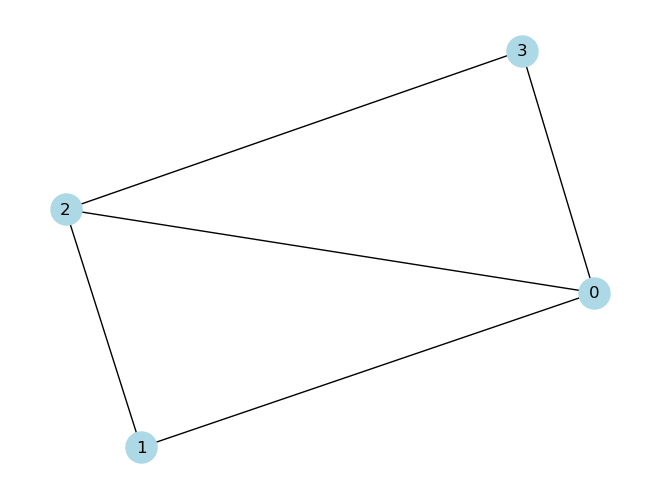

In [255]:
no_of_nodes = 5
edges = [(0, 1), (0, 2), (0, 4), (1, 2), (2, 3), (3, 4)]
weights = [1, 1, 1, 1, 1, 1]

no_of_nodes = 4
edges = [(0, 1), (0, 2), (0, 3), (1, 2), (2, 3)]
weights = [1, 1, 1, 1, 1]

G = rx.PyGraph()
G.add_nodes_from(range(no_of_nodes))
G.add_edges_from([(u, v, w) for (u, v), w in zip(edges, weights)])

draw_graph(G, with_labels=True, node_color="lightblue", node_size=500)


In [256]:
print('nodes:', list(G.nodes()))
print('edge weights:', list(G.edges()))
print('number of nodes:', G.num_nodes())
print('number of edges:', G.num_edges())

print('edge list:', G.edge_list())

nodes: [0, 1, 2, 3]
edge weights: [1, 1, 1, 1, 1]
number of nodes: 4
number of edges: 5
edge list: EdgeList[(0, 1), (0, 2), (0, 3), (1, 2), (2, 3)]


### Max-cut from Graph

Add weight/cost of edge if the two edge vertices are of different group

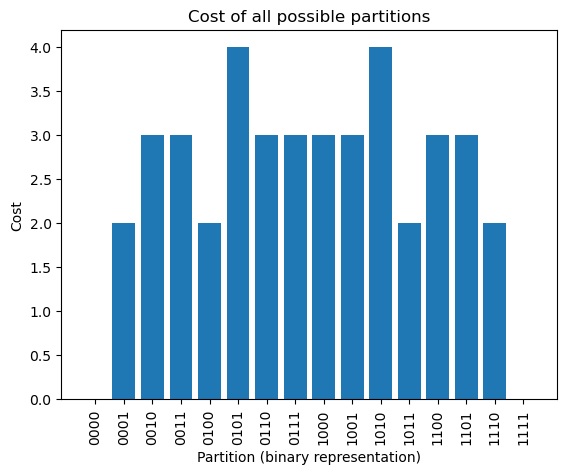

In [257]:
def cost_of_all_possible_partitions(G):

    edge_list = G.edge_list()
    edge_weights = list(G.edges())
    costs = []
    
    for i in range(2**G.num_nodes()):
        binary = format(i, f'0{G.num_nodes()}b')
        cost = 0
        for l,edge in enumerate(edge_list):
            if binary[edge[0]] != binary[edge[1]]:
                cost += edge_weights[l]
        costs.append(cost)
    return costs

costs = cost_of_all_possible_partitions(G)

bargraph = plt.bar([format(i, f'0{G.num_nodes()}b') for i in range(2**G.num_nodes())], costs)
plt.xlabel('Partition (binary representation)')
plt.ylabel('Cost')
plt.title('Cost of all possible partitions')
plt.xticks(rotation=90)
plt.show()

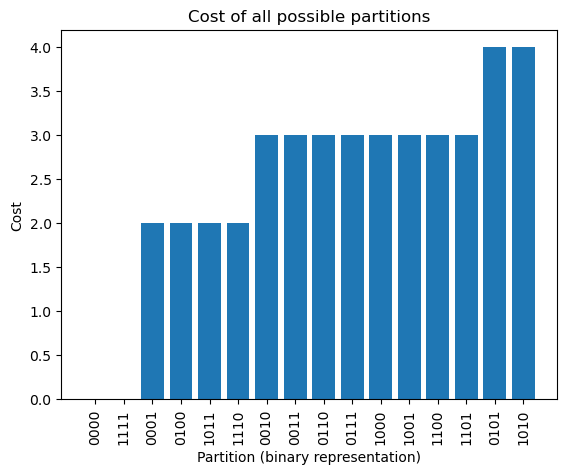

In [258]:

costs_sorted, node_bitstrings = zip(*sorted(zip(costs, [format(i, f'0{G.num_nodes()}b') for i in range(2**G.num_nodes())])))

bargraph = plt.bar(node_bitstrings, costs_sorted)
plt.xlabel('Partition (binary representation)')
plt.ylabel('Cost')
plt.title('Cost of all possible partitions')
plt.xticks(rotation=90)
plt.show()

In [259]:
Cut_values_and_Xs = sorted(zip(costs, [format(i, f'0{G.num_nodes()}b') for i in range(2**G.num_nodes())]))
Cut_values_and_Xs

[(0, '0000'),
 (0, '1111'),
 (2, '0001'),
 (2, '0100'),
 (2, '1011'),
 (2, '1110'),
 (3, '0010'),
 (3, '0011'),
 (3, '0110'),
 (3, '0111'),
 (3, '1000'),
 (3, '1001'),
 (3, '1100'),
 (3, '1101'),
 (4, '0101'),
 (4, '1010')]

In [260]:
print("Max-cut value:", Cut_values_and_Xs[-1][0])
print("Max-cut partition (binary):", Cut_values_and_Xs[-1][1])

Max-cut value: 4
Max-cut partition (binary): 1010



## Graded Exercise 2-2: MaxCut to Quadratic Program

**Exercise 2:**
Create a general QUBO cost function with QUBO Matrix Q = -W (negation of the weight matrix) and QUBO Vector c = sum of all entries in each row of the weight matrix W. 
Use binary optimisation variables in Quadratic Program and maximise it.



In [261]:
edge_list= G.edge_list()
edge_weights = list(G.edges())

W_mx = np.zeros((G.num_nodes(), G.num_nodes()))
for i, edge in enumerate(edge_list):
    W_mx[edge[0], edge[1]] = edge_weights[i]
    W_mx[edge[1], edge[0]] = edge_weights[i]

Q_mx = np.zeros((G.num_nodes(), G.num_nodes()))
for i, edge in enumerate(edge_list):
    Q_mx[edge[0], edge[1]] = -W_mx[edge[0], edge[1]]
    Q_mx[edge[1], edge[0]] = -W_mx[edge[1], edge[0]]

print("Q matrix:\n", Q_mx)

C_vector = np.zeros(G.num_nodes())
for i in range(G.num_nodes()):
    C_vector[i] = sum(W_mx[i, :])

print("C vector:\n", C_vector)


Q matrix:
 [[ 0. -1. -1. -1.]
 [-1.  0. -1.  0.]
 [-1. -1.  0. -1.]
 [-1.  0. -1.  0.]]
C vector:
 [3. 2. 3. 2.]


In [262]:
Q_row_sum = np.zeros(G.num_nodes())
for i in range(G.num_nodes()):
    Q_row_sum[i] = sum(Q_mx[i, :])

print("Row sum of Q matrix:\n", Q_row_sum)
print("C vector:\n", C_vector)


Row sum of Q matrix:
 [-3. -2. -3. -2.]
C vector:
 [3. 2. 3. 2.]


### Max-cut from Classical QUBO (Maximization) using brute force

Done only for graph with small no of vertices

In [263]:
import numpy as np

def qubo_objective(X, Q, C):
    """
    Compute X^T Q X + C_vector^T X for binary vector X, matrix Q, and vector C_vector
    """
    X = np.array(X)
    Q = np.array(Q)
    C = np.array(C)

    return X.T @ Q @ X + C.T @ X


# Example
n = 4
Q = Q_mx.copy()  # Use the Q matrix from earlier
C = C_vector.copy()  # Example linear term vector

max_QUBO_value = -10000000000
min_QUBO_value = 10000000000
max_X = None
min_X = None
for i in range(2**n):
    list_X = format(i, f'0{n}b')

    X = np.array(list(list_X)).astype(int)
    #X = np.array([1, 0, 1, 1])  # binary vector

    value = qubo_objective(X, Q, C)

    if value >= max_QUBO_value:
        max_QUBO_value = value
        max_X = X
    if value <= min_QUBO_value:
        min_QUBO_value = value
        min_X = X


print("maximum QUBO value: ", max_QUBO_value, "  at X =", max_X)
print("minimum QUBO value: ", min_QUBO_value, "  at X =", min_X)

Q


maximum QUBO value:  4.0   at X = [1 0 1 0]
minimum QUBO value:  0.0   at X = [1 1 1 1]


array([[ 0., -1., -1., -1.],
       [-1.,  0., -1.,  0.],
       [-1., -1.,  0., -1.],
       [-1.,  0., -1.,  0.]])

## Graded Exercise 2-3: Quantum Approximate Optimization Algorithm

**Exercise 3:**
For each layer i of p, use the following expression:
[Image: Screenshot 2021-08-06 at 4.10.10 AM.png] Use RZ, RZZ and RX gates to the expressions in their corresponding brackets as shown in the image above. While applying RZZ gates to Qjk, make sure that j is not equal to k else it would make it a single qubit and entanglement would not make sense. You can check how the final circuit looks like using the draw() function.


### Cost Hamiltonian from classical QUBO objective 

In [264]:
def Maxcut_to_Pauli(G):
    edge_list = G.edge_list()
    edge_weights = list(G.edges())
    pauli_list = []
    for l,edge in enumerate(edge_list):
        weight = edge_weights[l]
        pauli_list.append(('ZZ', [edge[0], edge[1]], Q_mx[edge[0], edge[1]]/4))
        pauli_list.append(('ZZ', [edge[1], edge[0]], Q_mx[edge[1], edge[0]]/4))
    for i in range(G.num_nodes()):
        pauli_list.append(('Z', [i], (Q_row_sum[i]/2 +C_vector[i]/2)))

    return pauli_list

Pauli_list = Maxcut_to_Pauli(G)
Cost_hamiltonian = SparsePauliOp.from_sparse_list(Pauli_list, num_qubits=G.num_nodes())
print('Pauli_list:      ', Pauli_list)
print('Cost_hamiltonian:',Cost_hamiltonian)

Pauli_list:       [('ZZ', [0, 1], np.float64(-0.25)), ('ZZ', [1, 0], np.float64(-0.25)), ('ZZ', [0, 2], np.float64(-0.25)), ('ZZ', [2, 0], np.float64(-0.25)), ('ZZ', [0, 3], np.float64(-0.25)), ('ZZ', [3, 0], np.float64(-0.25)), ('ZZ', [1, 2], np.float64(-0.25)), ('ZZ', [2, 1], np.float64(-0.25)), ('ZZ', [2, 3], np.float64(-0.25)), ('ZZ', [3, 2], np.float64(-0.25)), ('Z', [0], np.float64(0.0)), ('Z', [1], np.float64(0.0)), ('Z', [2], np.float64(0.0)), ('Z', [3], np.float64(0.0))]
Cost_hamiltonian: SparsePauliOp(['IIZZ', 'IIZZ', 'IZIZ', 'IZIZ', 'ZIIZ', 'ZIIZ', 'IZZI', 'IZZI', 'ZZII', 'ZZII', 'IIIZ', 'IIZI', 'IZII', 'ZIII'],
              coeffs=[-0.25+0.j, -0.25+0.j, -0.25+0.j, -0.25+0.j, -0.25+0.j, -0.25+0.j,
 -0.25+0.j, -0.25+0.j, -0.25+0.j, -0.25+0.j,  0.  +0.j,  0.  +0.j,
  0.  +0.j,  0.  +0.j])


In [265]:
'''
def Maxcut_to_Pauli(G):
    edge_list = G.edge_list()
    edge_weights = list(G.edges())
    pauli_list = []
    for l,edge in enumerate(edge_list):
        weight = edge_weights[l]
        pauli_list.append(('ZZ', [edge[0], edge[1]], weight))
    return pauli_list

Pauli_list = Maxcut_to_Pauli(G)
Cost_hamiltonian = SparsePauliOp.from_sparse_list(Pauli_list, num_qubits=G.num_nodes())
print('Pauli_list:      ', Pauli_list)
print('Cost_hamiltonian:',Cost_hamiltonian)
'''

"\ndef Maxcut_to_Pauli(G):\n    edge_list = G.edge_list()\n    edge_weights = list(G.edges())\n    pauli_list = []\n    for l,edge in enumerate(edge_list):\n        weight = edge_weights[l]\n        pauli_list.append(('ZZ', [edge[0], edge[1]], weight))\n    return pauli_list\n\nPauli_list = Maxcut_to_Pauli(G)\nCost_hamiltonian = SparsePauliOp.from_sparse_list(Pauli_list, num_qubits=G.num_nodes())\nprint('Pauli_list:      ', Pauli_list)\nprint('Cost_hamiltonian:',Cost_hamiltonian)\n"

### QAOA Ansatz

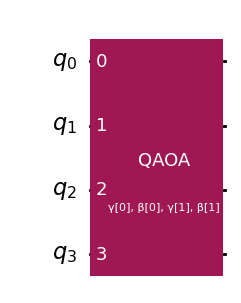

In [266]:
circuit = QAOAAnsatz(cost_operator=Cost_hamiltonian, reps=2)
#circuit.measure_all()

circuit.draw("mpl")

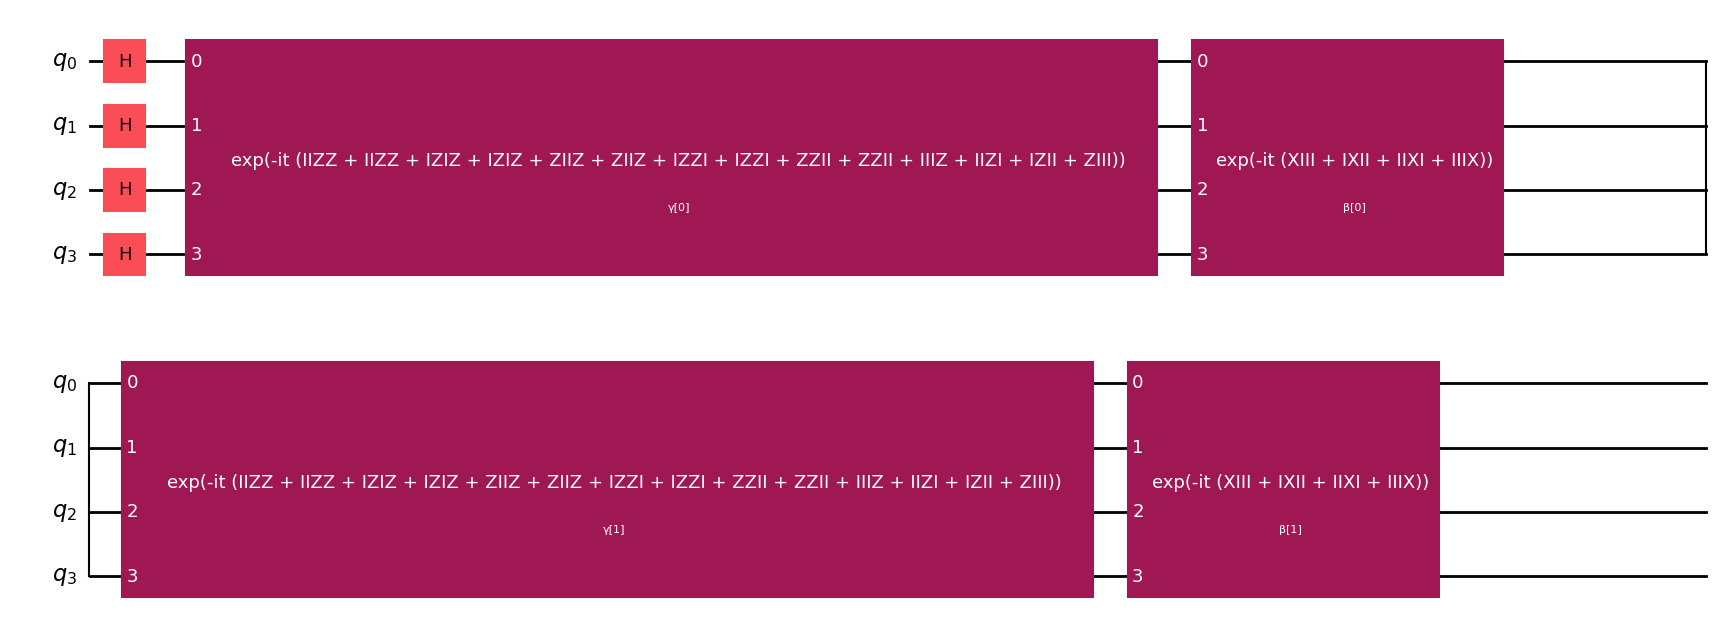

In [267]:
circuit.decompose().draw("mpl")

In [268]:
circuit.parameters

ParameterView([ParameterVectorElement(β[0]), ParameterVectorElement(β[1]), ParameterVectorElement(γ[0]), ParameterVectorElement(γ[1])])

In [269]:
circuit.parameters[0]

ParameterVectorElement(β[0])

In [270]:
# Bind parameters to values
#bound_circuit = circuit.bind_parameters({theta: 0.5, phi: 1.2})

# Or use parameter_bind_dict for mapping
binding_dict = {param: value for param, value in zip(circuit.parameters, [0.5, 0.8, 1, 1.2])}
bound_circuit = circuit.assign_parameters(binding_dict)

In [271]:
binding_dict

{ParameterVectorElement(β[0]): 0.5,
 ParameterVectorElement(β[1]): 0.8,
 ParameterVectorElement(γ[0]): 1,
 ParameterVectorElement(γ[1]): 1.2}

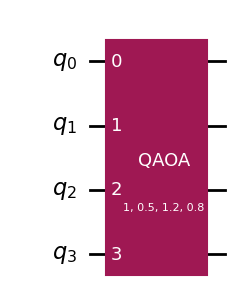

In [272]:
bound_circuit.draw("mpl")

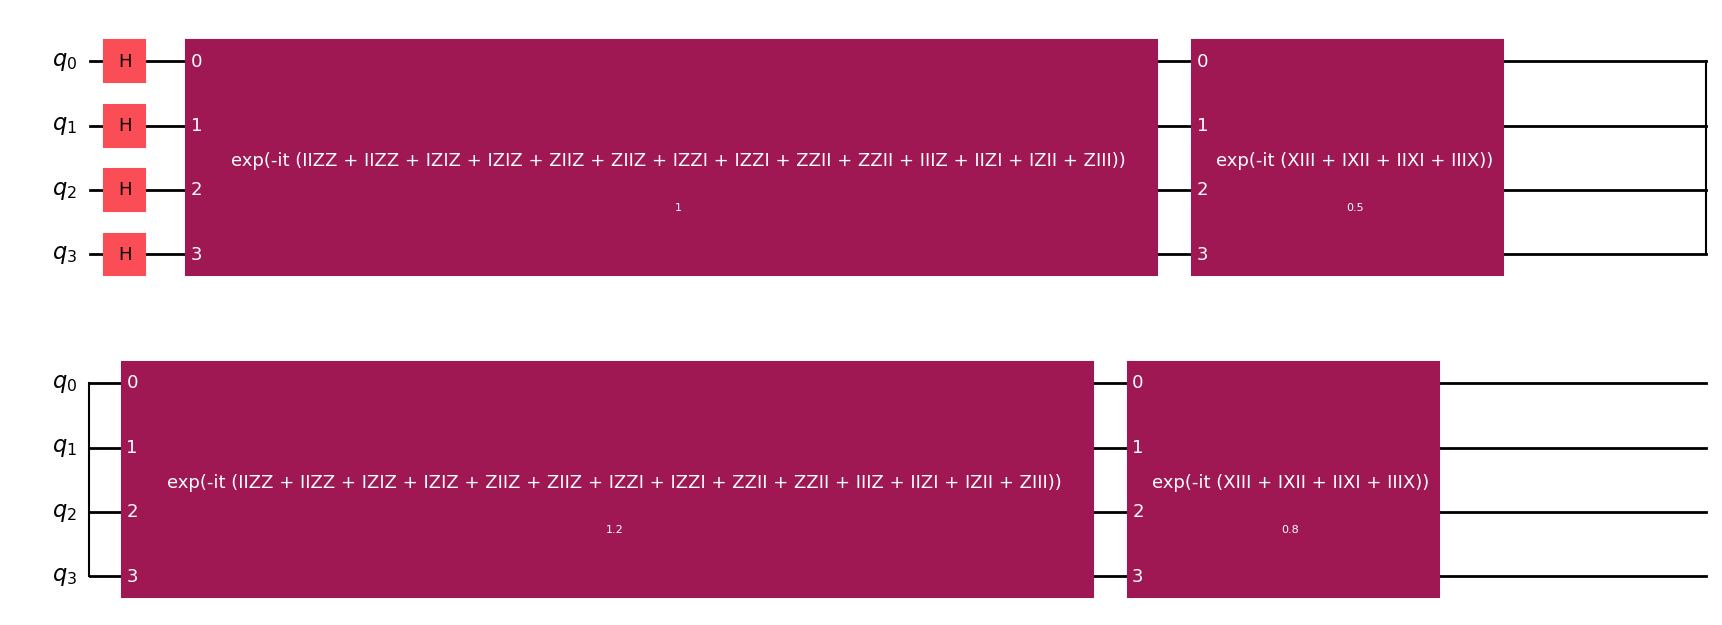

In [273]:
bound_circuit.decompose().draw("mpl")

### Transpile the QAOA Ansatz circuit to AerSimulator circuit

Method used: statevector

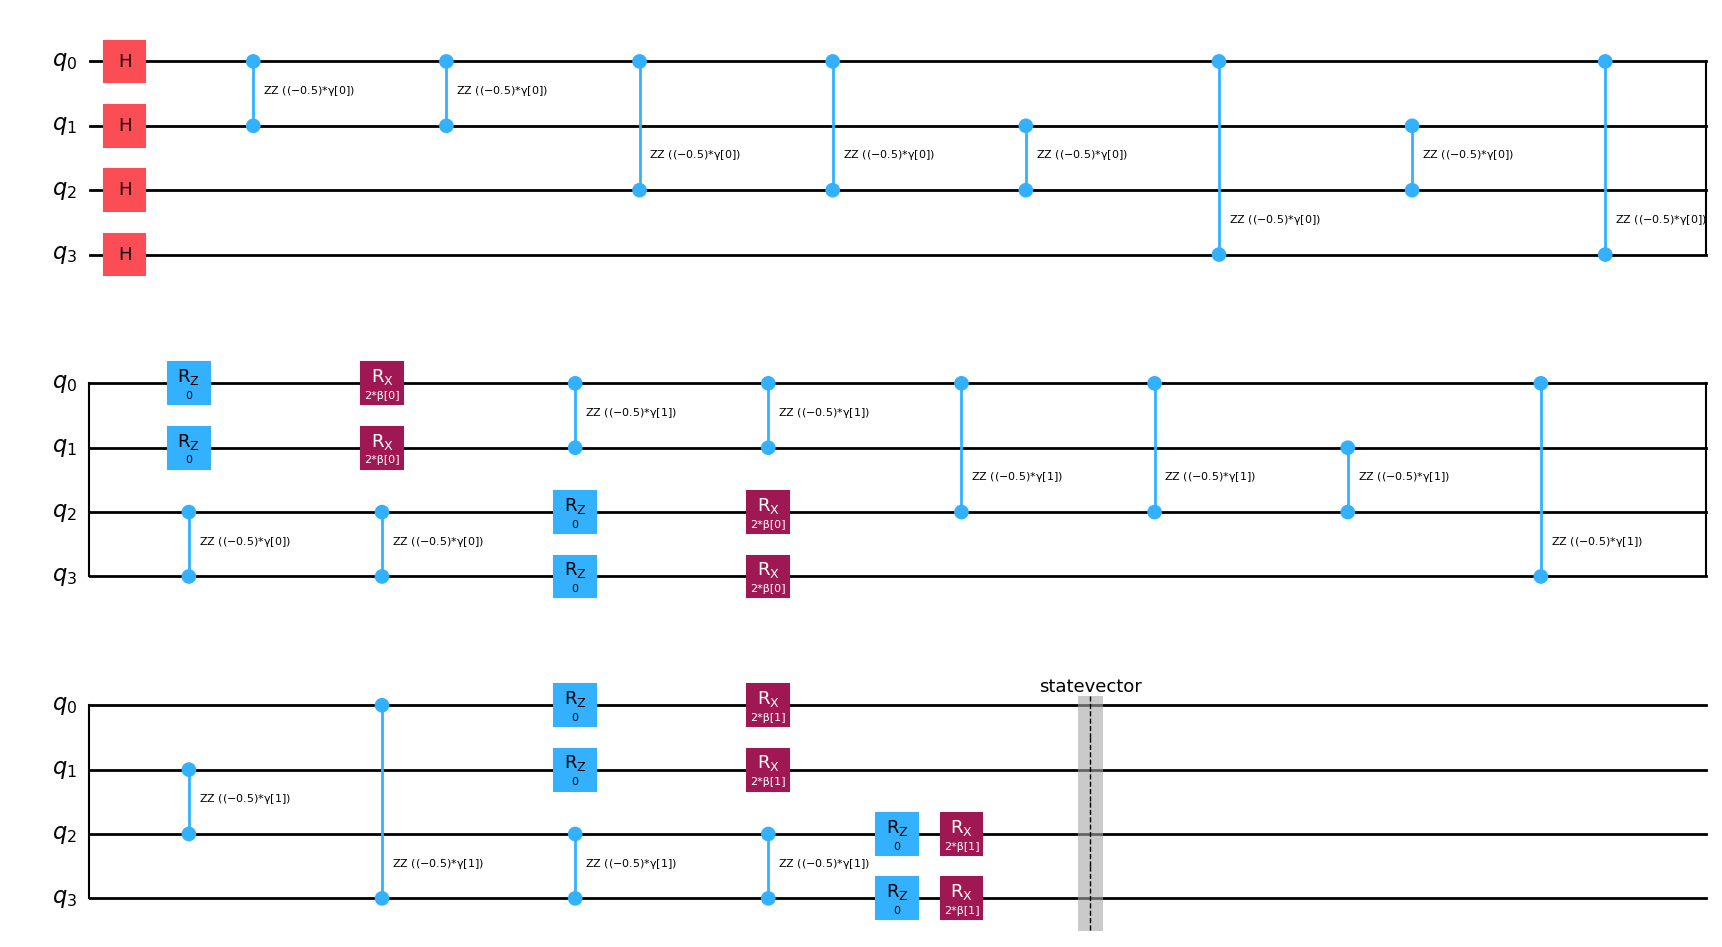

In [274]:
simulator = AerSimulator(method='statevector')
Aer_transpiled_ckt = transpile(circuit, simulator)

Aer_transpiled_ckt.save_statevector()

Aer_transpiled_ckt.draw("mpl")

### State Vector of Simulator (without measurement) 

State vector

State city visualization

In [275]:
results = simulator.run(Aer_transpiled_ckt).result()
counts = results.get_counts()
plot_histogram(counts, title="State Vector without measurement")

AerError: 'circuits have parameters but parameter_binds is not specified.'

In [ ]:
sum_=0
for value in list(counts.values()):
    sum_ += value
print("Total shots:", sum_)

Total shots: 1.0


In [ ]:
state_vector = results.get_statevector()
state_vector

Statevector([ 0.29985811+0.09656708j,  0.17989049+0.04363568j,
              0.24565796+0.05122825j,  0.0154633 -0.02981319j,
              0.17989049+0.04363568j, -0.28179463+0.35301865j,
              0.0154633 -0.02981319j,  0.24565796+0.05122825j,
              0.24565796+0.05122825j,  0.0154633 -0.02981319j,
             -0.28179463+0.35301865j,  0.17989049+0.04363568j,
              0.0154633 -0.02981319j,  0.24565796+0.05122825j,
              0.17989049+0.04363568j,  0.29985811+0.09656708j],
            dims=(2, 2, 2, 2))


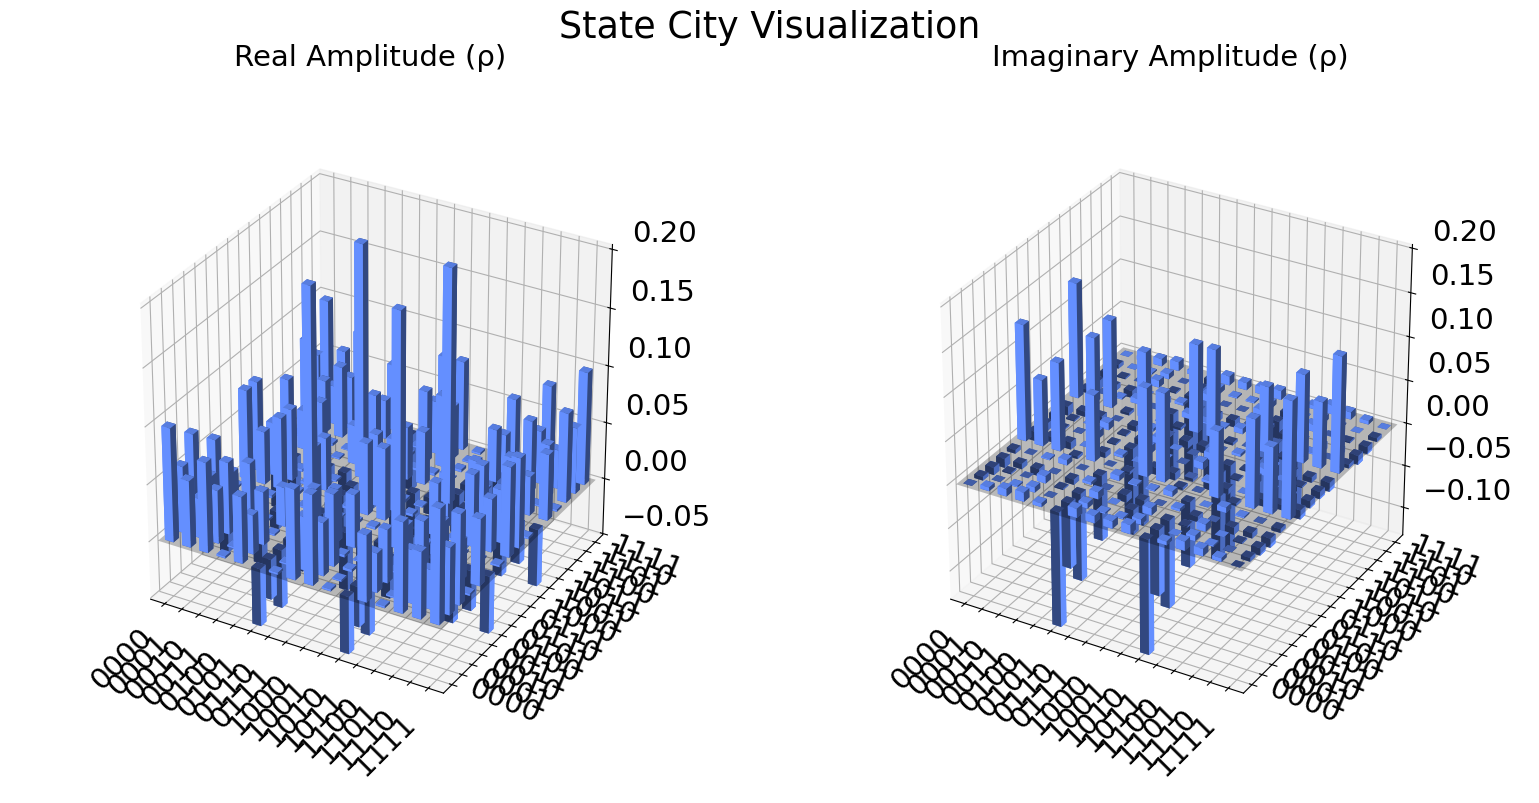

In [ ]:
plot_state_city(state_vector, title="State City Visualization")

### Parameter Optimization of Transpiled AerSimulator Circuit

In [359]:
def Average_Energy(parameter_values, transiled_circuit, Cost_hamiltonian, estimator):
    # Bind the parameters to the circuit
    binding_dict = {param: value for param, value in zip(transiled_circuit.parameters, parameter_values)}
    bound_circuit = transiled_circuit.assign_parameters(binding_dict)

    #isa_hamiltonian = Cost_hamiltonian.apply_layout(bound_circuit.layout)
    isa_hamiltonian = Cost_hamiltonian.apply_layout(transiled_circuit.layout)

    #display(bound_circuit.draw("mpl"))

    # Simulate the circuit to get the state vector
    #simulator = AerSimulator(method='statevector')
    #transpiled_ckt = transpile(bound_circuit, simulator)

    #print(Cost_hamiltonian)
    #print(isa_hamiltonian)
    
    #print(transiled_circuit.parameters)
    #print(len(transiled_circuit.parameters))

    #print(bound_circuit.parameters)
    #print(len(bound_circuit.parameters))

    pub = (transiled_circuit, isa_hamiltonian, parameter_values)
    #pub = (bound_circuit, isa_hamiltonian, parameter_values)
    results = estimator.run([pub]).result()

    #print(results[0].data.evs)

    #state_vector = results[0].get_statevector()

    stateVect = np.array(state_vector)
    cost_Mx = np.array(Cost_hamiltonian.to_matrix())


    # Compute the expectation value of the cost Hamiltonian
    #energy = np.real(state_vector.conj().T @ Cost_hamiltonian.to_matrix() @ state_vector)
    energy = np.real(stateVect.conj().T @ cost_Mx @ stateVect)

    #print("Expected Values:", results[0].data.evs)
    #print("Energy:", energy)

    return results[0].data.evs # energy

In [382]:
estimator = Estimator(mode=simulator)
estimator.options.default_shots = 1000000
#init_param_values = [0.5, 0.8, 1, 1.2] # [np.pi / 2, np.pi / 2, np.pi / 2, np.pi / 2]
init_param_values = [np.pi / 2, np.pi / 2, np.pi / 2, np.pi / 2]
energy = Average_Energy(init_param_values, Aer_transpiled_ckt, Cost_hamiltonian, estimator)

print('Energy:', energy)
print('State vector:', state_vector)

Energy: -0.001418
State vector: Statevector([ 0.29985811+0.09656708j,  0.17989049+0.04363568j,
              0.24565796+0.05122825j,  0.0154633 -0.02981319j,
              0.17989049+0.04363568j, -0.28179463+0.35301865j,
              0.0154633 -0.02981319j,  0.24565796+0.05122825j,
              0.24565796+0.05122825j,  0.0154633 -0.02981319j,
             -0.28179463+0.35301865j,  0.17989049+0.04363568j,
              0.0154633 -0.02981319j,  0.24565796+0.05122825j,
              0.17989049+0.04363568j,  0.29985811+0.09656708j],
            dims=(2, 2, 2, 2))


In [383]:
result = minimize(
        Average_Energy,
        init_param_values,
        args=(Aer_transpiled_ckt, Cost_hamiltonian, estimator),
        method="COBYLA",
        tol=1e-2,
)

print("Optimal parameters:", result.x)
print("Minimum energy:", result.fun)

Optimal parameters: [2.52139525 3.4541948  1.01311742 2.40008923]
Minimum energy: -1.959215


In [384]:
result = minimize(
        Average_Energy,
        init_param_values,
        args=(Aer_transpiled_ckt, -Cost_hamiltonian, estimator),
        method="COBYLA",
        tol=1e-2,
)

print("Optimal parameters:", result.x)
print("Maximum energy:", -result.fun)

Optimal parameters: [ 0.70824651  1.89716375  3.98237004 -2.70449617]
Maximum energy: 1.355809


In [344]:
print(Cost_hamiltonian)
print('-'*100)
print(SparsePauliOp.from_list(Cost_hamiltonian.to_list()))

SparsePauliOp(['IIZZ', 'IIZZ', 'IZIZ', 'IZIZ', 'ZIIZ', 'ZIIZ', 'IZZI', 'IZZI', 'ZZII', 'ZZII', 'IIIZ', 'IIZI', 'IZII', 'ZIII'],
              coeffs=[-0.25+0.j, -0.25+0.j, -0.25+0.j, -0.25+0.j, -0.25+0.j, -0.25+0.j,
 -0.25+0.j, -0.25+0.j, -0.25+0.j, -0.25+0.j,  0.  +0.j,  0.  +0.j,
  0.  +0.j,  0.  +0.j])
----------------------------------------------------------------------------------------------------
SparsePauliOp(['IIZZ', 'IIZZ', 'IZIZ', 'IZIZ', 'ZIIZ', 'ZIIZ', 'IZZI', 'IZZI', 'ZZII', 'ZZII', 'IIIZ', 'IIZI', 'IZII', 'ZIII'],
              coeffs=[-0.25+0.j, -0.25+0.j, -0.25+0.j, -0.25+0.j, -0.25+0.j, -0.25+0.j,
 -0.25+0.j, -0.25+0.j, -0.25+0.j, -0.25+0.j,  0.  +0.j,  0.  +0.j,
  0.  +0.j,  0.  +0.j])


In [345]:

print(circuit.parameters)
print(len(circuit.parameters))

print(bound_circuit.parameters)
print(len(bound_circuit.parameters))

print(Aer_transpiled_ckt.parameters)
print(len(Aer_transpiled_ckt.parameters))

ParameterView([ParameterVectorElement(β[0]), ParameterVectorElement(β[1]), ParameterVectorElement(γ[0]), ParameterVectorElement(γ[1])])
4
ParameterView([])
0
ParameterView([ParameterVectorElement(β[0]), ParameterVectorElement(β[1]), ParameterVectorElement(γ[0]), ParameterVectorElement(γ[1])])
4


In [346]:
print(len(state_vector.conj().T))
print(len(Cost_hamiltonian.to_matrix()))

16
16


C:\Users\kcrav\AppData\Local\Temp\ipykernel_13400\659398804.py:1: DeprecationWarning: The return type of saved statevectors has been changed from a `numpy.ndarray` to a `qiskit.quantum_info.Statevector` as of qiskit-aer 0.10. Accessing numpy array attributes is deprecated and will result in an error in a future release. To continue using saved result objects as arrays you can explicitly cast them using  `np.asarray(object)`.
  print(len(state_vector.conj().T))




## Graded Exercise 2-4: Conditional Value at Risk

**Exercise 4:**
Do not forget to order the cut-values Ci in decreasing order!
Simply get the number of best cuts n that are to be considered for our optimisation process by multiplying the number of shots by alpha. 
The top n cuts would be the first n Ci. 
Finally, calculate the energy.